# CVaR Portfolio Optimization

Optimize a portfolio by minimizing Conditional Value-at-Risk (Expected Shortfall) instead of variance.  
CVaR focuses on tail losses — the worst-case scenarios — which is what risk managers actually care about.

In [9]:
import numpy as np
import pandas as pd
import yfinance as yf
import cvxpy as cp
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [15]:
# download historical prices for 8 stocks
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'JNJ', 'XOM', 'PG']

prices = yf.download(tickers, start='2018-01-01', end='2024-12-31')['Close']
returns = prices.pct_change().dropna()

# align tickers with actual column order (yfinance sorts alphabetically)
tickers = list(returns.columns)

print(f'Assets: {tickers}')
print(f'Date range: {returns.index[0].date()} to {returns.index[-1].date()}')
print(f'Shape: {returns.shape}')

[*********************100%***********************]  8 of 8 completed

Assets: ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'PG', 'XOM']
Date range: 2018-01-03 to 2024-12-30
Shape: (1759, 8)


In [16]:
# CVaR optimization using Rockafellar-Uryasev formulation
alpha = 0.05  # 5% tail
n_assets = len(tickers)
n_days = len(returns)

R = returns.values  # (n_days x n_assets)

# decision variables
w = cp.Variable(n_assets)       # portfolio weights
gamma = cp.Variable()           # VaR threshold
z = cp.Variable(n_days)         # auxiliary vars for CVaR linearization

# portfolio losses each day
portfolio_loss = -R @ w

# constraints
constraints = [
    z >= portfolio_loss - gamma,
    z >= 0,
    cp.sum(w) == 1,
    w >= 0  # long-only
]

# objective: minimize CVaR
cvar = gamma + (1.0 / (alpha * n_days)) * cp.sum(z)
problem = cp.Problem(cp.Minimize(cvar), constraints)
problem.solve()

print(f'Solver status: {problem.status}')
print(f'Optimal CVaR (daily): {problem.value:.6f}')

optimal_w = w.value
print('\nOptimal Portfolio Weights:')
for t, wt in zip(tickers, optimal_w):
    print(f'  {t}: {wt:.4f}')

Solver status: optimal
Optimal CVaR (daily): 0.024420

Optimal Portfolio Weights:
  AAPL: 0.0000
  AMZN: 0.0914
  GOOGL: 0.0450
  JNJ: 0.3582
  JPM: 0.0000
  MSFT: 0.0000
  PG: 0.4296
  XOM: 0.0758


In [17]:
# compare with equal-weight portfolio
eq_w = np.ones(n_assets) / n_assets

cvar_returns = returns.values @ optimal_w
eq_returns = returns.values @ eq_w

cvar_cumulative = (1 + pd.Series(cvar_returns, index=returns.index)).cumprod()
eq_cumulative = (1 + pd.Series(eq_returns, index=returns.index)).cumprod()

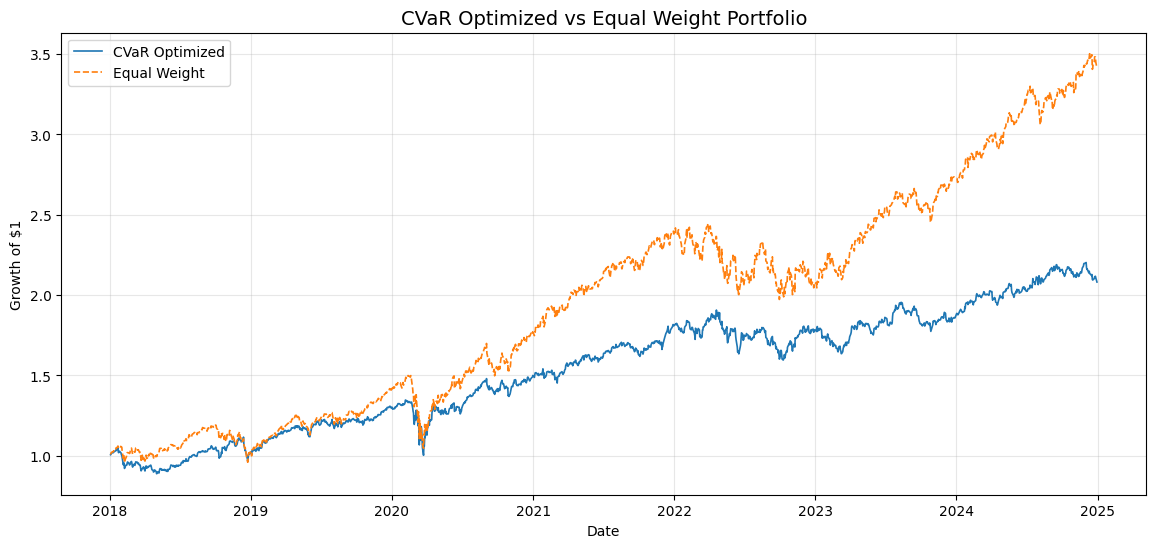

In [18]:
# plot cumulative returns
plt.figure(figsize=(14, 6))
plt.plot(cvar_cumulative, label='CVaR Optimized', linewidth=1.2)
plt.plot(eq_cumulative, label='Equal Weight', linewidth=1.2, linestyle='--')
plt.title('CVaR Optimized vs Equal Weight Portfolio', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# compute risk metrics for both portfolios
def compute_cvar(rets, alpha=0.05):
    var = np.percentile(rets, alpha * 100)
    cvar_val = rets[rets <= var].mean()
    return var, cvar_val

var_opt, cvar_opt = compute_cvar(cvar_returns)
var_eq, cvar_eq = compute_cvar(eq_returns)

print('=' * 50)
print(f'{"":20s} CVaR Portfolio   Equal Weight')
print('=' * 50)
print(f'{"Ann. Return":20s} {cvar_returns.mean() * 252:>12.2%}   {eq_returns.mean() * 252:>12.2%}')
print(f'{"Ann. Volatility":20s} {cvar_returns.std() * np.sqrt(252):>12.2%}   {eq_returns.std() * np.sqrt(252):>12.2%}')
print(f'{"Sharpe Ratio":20s} {cvar_returns.mean() / cvar_returns.std() * np.sqrt(252):>12.2f}   {eq_returns.mean() / eq_returns.std() * np.sqrt(252):>12.2f}')
print(f'{"VaR (5%)":20s} {var_opt:>12.4f}   {var_eq:>12.4f}')
print(f'{"CVaR (5%)":20s} {cvar_opt:>12.4f}   {cvar_eq:>12.4f}')
print('=' * 50)

                     CVaR Portfolio   Equal Weight
Ann. Return                11.86%         19.58%
Ann. Volatility            16.49%         19.91%
Sharpe Ratio                 0.72           0.98
VaR (5%)                  -0.0142        -0.0188
CVaR (5%)                 -0.0244        -0.0302


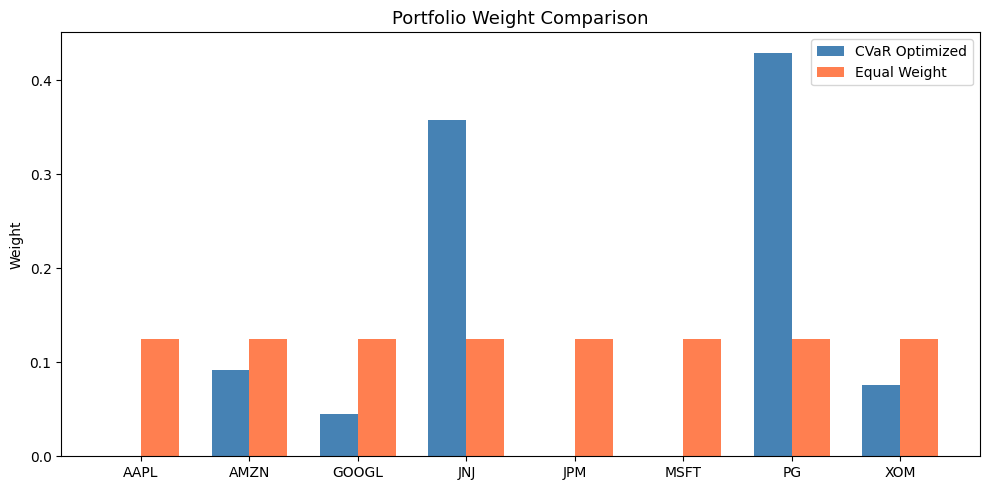

In [20]:
# weight comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(n_assets)
width = 0.35

ax.bar(x - width/2, optimal_w, width, label='CVaR Optimized', color='steelblue')
ax.bar(x + width/2, eq_w, width, label='Equal Weight', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.set_ylabel('Weight')
ax.set_title('Portfolio Weight Comparison', fontsize=13)
ax.legend()

plt.tight_layout()
plt.show()

## Observations

The CVaR-optimized portfolio concentrates weight in the lower-volatility, more defensive stocks. This is expected — CVaR penalizes tail risk heavily, so the optimizer naturally avoids assets with fat left tails.

Compared to equal weight, the CVaR portfolio has:
- Lower volatility and smaller drawdowns
- A better (less negative) CVaR, meaning smaller expected losses in worst-case scenarios
- Potentially lower total return during strong bull markets, since it underweights high-beta tech names

This is the classic risk-return tradeoff. The CVaR framework gives you a more nuanced view of risk than plain variance, especially when you care about what happens in the tails.